In [1]:
PATH_TO_INSTANCES = "/home/felix/pCloudDrive/research/asforests/problem instances with detailed scores"

In [2]:
import numpy as np
from py_experimenter.experimenter import PyExperimenter
import pathlib
import seaborn as sb
import matplotlib.pyplot as plt
import openml

An openml configuration file was found at the old location at /home/felix/.config/config. We have copied it to the new location at /home/felix/.config/openml/config. 
To silence this warning please verify that the configuration file at /home/felix/.config/openml/config is correct and delete the file at /home/felix/.config/config.


In [3]:
d_datasets = [3, 12, 23, 31, 54, 181, 188, 1049, 1067, 1111, 1169, 1457, 1461, 1464, 1468, 1475, 1486, 1487, 1489, 1494, 1515, 1590, 1596, 4134, 4135, 4534, 4538, 4541, 23517, 40498, 40668, 40670, 40685, 40701, 40900, 40975, 40978, 40981, 40982, 40983, 40984, 40996, 41027, 41138, 41142, 41143, 41144, 41145, 41146, 41147, 41150, 41156, 41157, 41158, 41159, 41161, 41162, 41163, 41164, 41165, 41166, 41167, 41168, 41169, 42732, 42733, 42734, 42742, 42746, 42769, 43072]
d_num_possible_ensemble_members = [1, 8, 64, 256]
d_data_seed = list(range(10))
d_validation_instances = [2, 8, 64, 256]

In [4]:
for dataset_id in d_datasets:
    dataset = openml.datasets.get_dataset(dataset_id, download_data=False)

    # Use the dataset's "features" dictionary
    num_instances = int(dataset.qualities['NumberOfInstances'])
    num_features = len(dataset.features)  # includes all attributes

    # Optionally, subtract the target column if you want features only
    if dataset.default_target_attribute:
        num_features -= 1

    if num_instances <= 10000:
        print(dataset_id, f"Shape of X: ({num_instances}, {num_features})")

3 Shape of X: (3196, 36)
12 Shape of X: (2000, 216)
23 Shape of X: (1473, 9)
31 Shape of X: (1000, 20)
54 Shape of X: (846, 18)
181 Shape of X: (1484, 8)
188 Shape of X: (736, 19)
1049 Shape of X: (1458, 37)
1067 Shape of X: (2109, 21)
1457 Shape of X: (1500, 10000)
1464 Shape of X: (748, 4)
1468 Shape of X: (1080, 856)
1475 Shape of X: (6118, 51)
1487 Shape of X: (2534, 72)
1489 Shape of X: (5404, 5)
1494 Shape of X: (1055, 41)
1515 Shape of X: (571, 1300)
4134 Shape of X: (3751, 1776)
4538 Shape of X: (9873, 32)
40498 Shape of X: (4898, 11)
40670 Shape of X: (3186, 180)
40701 Shape of X: (5000, 20)
40900 Shape of X: (5100, 36)
40975 Shape of X: (1728, 6)
40978 Shape of X: (3279, 1558)
40981 Shape of X: (690, 14)
40982 Shape of X: (1941, 27)
40983 Shape of X: (4839, 5)
40984 Shape of X: (2310, 19)
41142 Shape of X: (5418, 1636)
41143 Shape of X: (2984, 144)
41144 Shape of X: (3140, 259)
41145 Shape of X: (5832, 308)
41146 Shape of X: (5124, 20)
41156 Shape of X: (4147, 48)
41157 Shape

In [5]:
def get_path(openmlid, num_possible_ensemble_members, data_seed, validation_instances):
    return pathlib.Path(f"{PATH_TO_INSTANCES}/{openmlid}/{openmlid}_{data_seed}_{num_possible_ensemble_members}_{validation_instances}.json.gz")

In [16]:
availability = np.zeros((len(d_datasets), len(d_num_possible_ensemble_members), len(d_data_seed), len(d_validation_instances)))
for i1, openmlid in enumerate(d_datasets):
    for i2, num_possible_ensemble_members in enumerate(d_num_possible_ensemble_members):
        for i3, data_seed in enumerate(d_data_seed):
            for i4, validation_instances in enumerate(d_validation_instances):
                if get_path(openmlid=openmlid, num_possible_ensemble_members=num_possible_ensemble_members, data_seed=data_seed, validation_instances=validation_instances).exists():
                    availability[i1, i2, i3, i4] = 1


required = np.ones_like(availability)

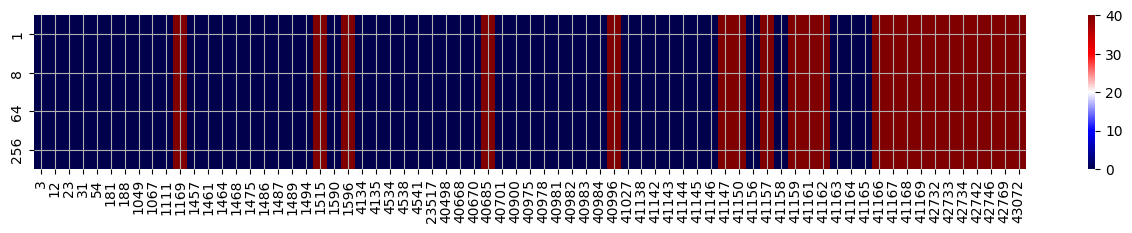

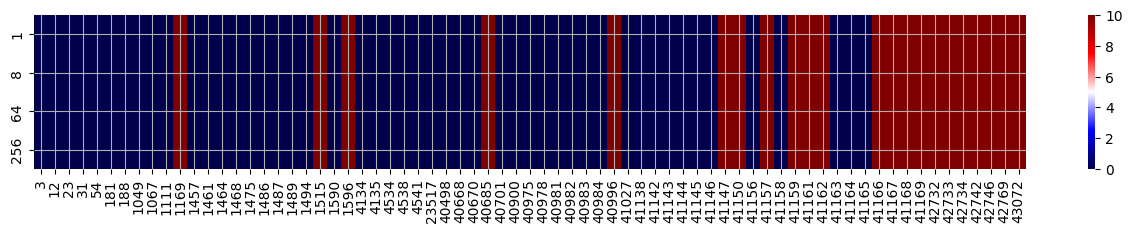

In [17]:
for vmax in [
    40,
    10
    ]:
    fig, ax = plt.subplots(figsize=(16, 2))
    sb.heatmap((required - availability).sum(axis=(2, 3)).T, vmin=0, vmax=vmax, cmap="seismic")
    ax.set_xticks(np.arange(len(d_datasets)) + 0.5)
    ax.set_xticklabels(d_datasets, rotation=90)
    ax.set_yticklabels(d_num_possible_ensemble_members)
    ax.grid()
    plt.show()